# Visualize neural recordings

VneuroTK's `viz` extra provides Matplotlib plots of stimulus timing and neural activity. It is separate from `vneurotk.vision`, which extracts representations with deep neural network (DNN) vision models.

**Prerequisites:** install VneuroTK with the visualization and notebook extras, for example `uv add "vneurotk[viz,notebook]"`. This guide is offline and uses deterministic synthetic data.

## Plot continuous data with `BaseData.plot`

Create a sampled recording, configure stimulus onsets, and ask the data object to build the standard two-panel figure. The upper panel shows trial labels and relative trial time; the lower panel is a channel-by-time heatmap.

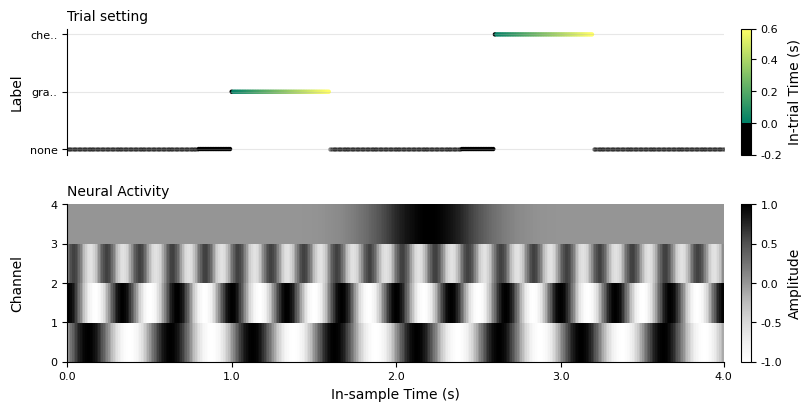

In [1]:
import numpy as np
from loguru import logger

import vneurotk as vtk

logger.remove()

t = np.arange(400) / 100.0
continuous_neuro = np.column_stack(
    [
        np.sin(2 * np.pi * 2 * t),
        np.cos(2 * np.pi * 3 * t),
        0.6 * np.sin(2 * np.pi * 5 * t + 0.4),
        np.exp(-(((t - 2.2) / 0.35) ** 2)),
    ]
)
continuous = vtk.BaseData.for_continuous(
    continuous_neuro,
    neuro_info={"ch_names": ["V1", "V2", "V3", "V4"], "sfreq": 100.0},
)
continuous.configure(
    stim_ids=["grating", "checkerboard"],
    vision_onsets=np.array([100, 260]),
    trial_window=[-20, 60],
)

continuous_figure = continuous.plot(window=(0, 400), figsize=(8, 4))
continuous_figure

`window=(0, 400)` uses **integer sample indices**. Non-integral real bounds use **seconds**, so `window=(0.8, 2.0)` selects the same kind of interval in physical time. Keep the numeric types intentional: `2` means sample 2, while `2.0` means 2 seconds.

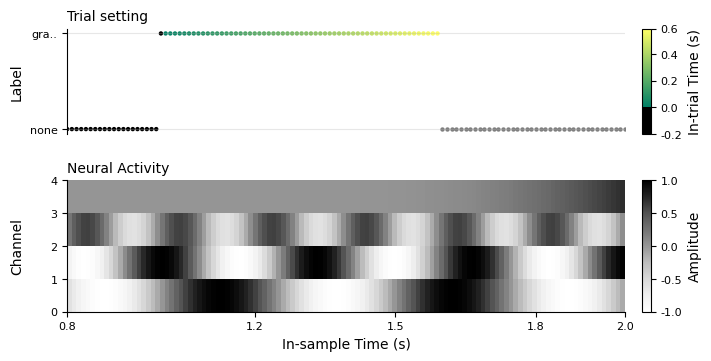

In [2]:
seconds_figure = continuous.plot(window=(0.8, 2.0), figsize=(7, 3.5))
seconds_figure

## Plot pre-epoched data

`BaseData.plot` also accepts `epochs` mode. It flattens the trial and time axes for display while preserving each trial's configured onset and label.

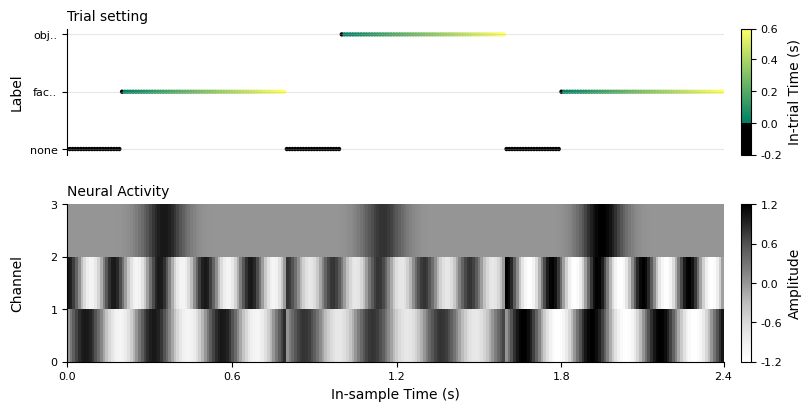

In [3]:
epoch_time = np.arange(80) / 100.0
base_epoch = np.column_stack(
    [
        np.sin(2 * np.pi * 4 * epoch_time),
        np.cos(2 * np.pi * 6 * epoch_time),
        np.exp(-(((epoch_time - 0.35) / 0.08) ** 2)),
    ]
)
epoch_neuro = np.stack([base_epoch, 0.8 * base_epoch, 1.2 * base_epoch])
epochs = vtk.BaseData.for_epochs(
    epoch_neuro,
    neuro_info={"ch_names": ["occipital", "temporal", "parietal"], "sfreq": 100.0},
)
epochs.configure(
    stim_ids=["face", "object", "face"],
    vision_onsets=np.array([20, 20, 20]),
)

epoch_figure = epochs.plot(window=(0, 240), figsize=(8, 4))
epoch_figure

## Call `vneurotk.viz.plot_data` directly

Use the lower-level function when arrays are not wrapped in `BaseData`. `neuro` must be samples by channels, and `visual` must provide one stimulus label (or `None`) per sample.

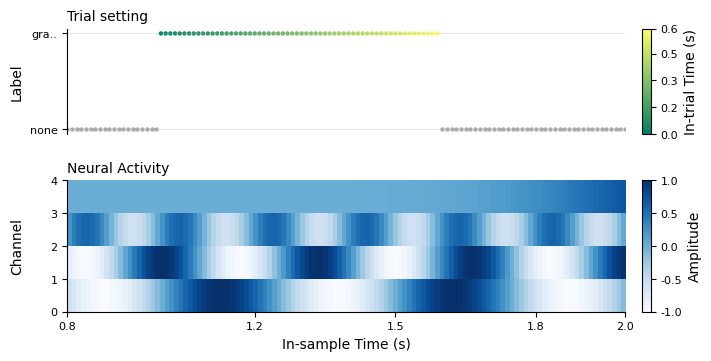

In [4]:
labels = np.full(len(t), None, dtype=object)
labels[100:160] = "grating"
labels[260:320] = "checkerboard"

direct_figure = vtk.viz.plot_data(
    neuro=continuous_neuro,
    visual=labels,
    sfreq=100.0,
    window=(80, 200),
    figsize=(7, 3.5),
    cmap_neuro="Blues",
    color_offtime="0.35",
)
direct_figure

## Figure ownership and supported data

Both APIs create and return a Matplotlib `Figure`; the caller owns it. Keep the return value to annotate or save it, and call `plt.close(figure)` when a script no longer needs it. Notebook display keeps these figures open so their committed PNG output remains visible.

Visualization is limited to recordings with a time axis: continuous and epoched data. `patterns` mode contains aggregated rows rather than time samples, so `BaseData.plot()` rejects it.

## Related documentation

- {doc}`Build neural data <data>`
- {doc}`Complete evoked-response example <../example_ipynb/viz>`
- [Visualization API](../api/viz.md)
- {doc}`DNN vision model usage <vision_models>`